In [1]:
import pandas as pd
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
df['Glucose'] = df['Glucose'].replace(0,df['Glucose'].median())

In [8]:
df['BloodPressure'] = df['BloodPressure'].replace(0,df['BloodPressure'].median())

In [9]:
df['SkinThickness'] = df['SkinThickness'].replace(0,df['SkinThickness'].median())

In [10]:
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].median())

In [11]:
df['BMI']= df['BMI'].replace(0,df['BMI'].median())

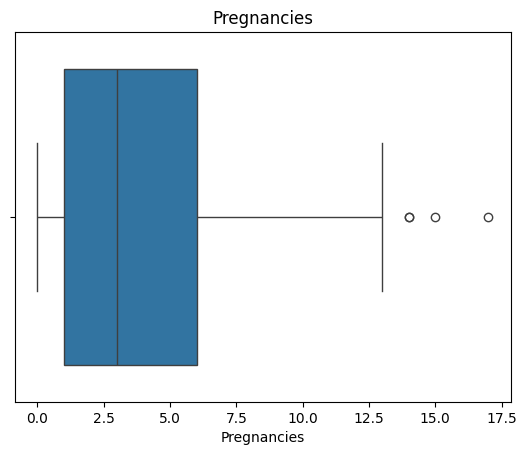

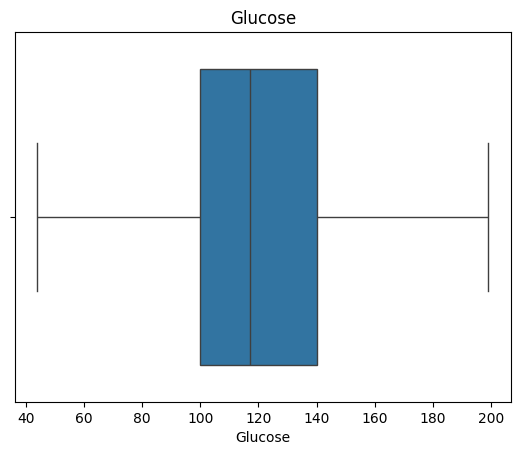

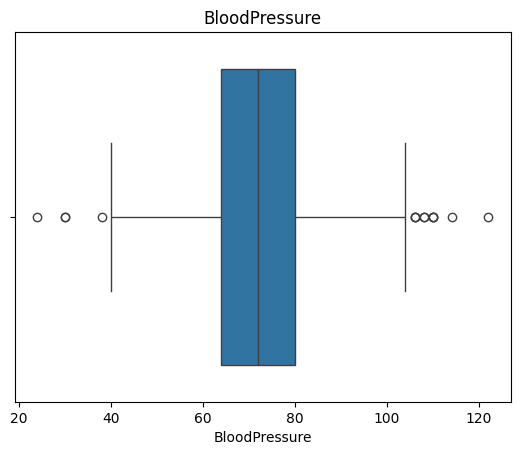

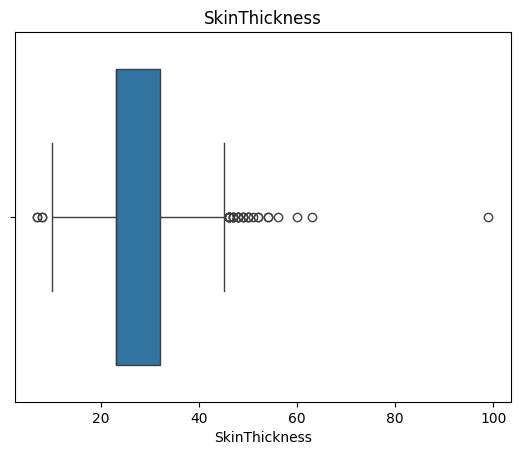

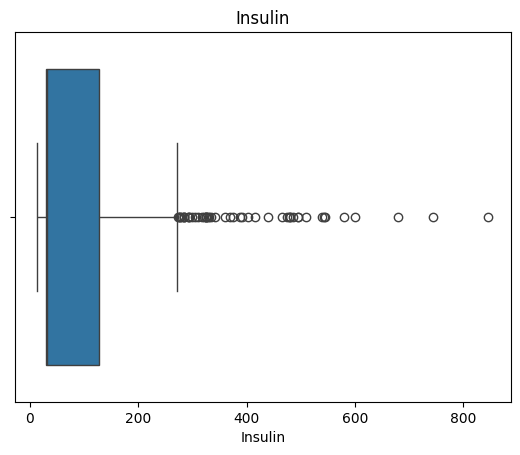

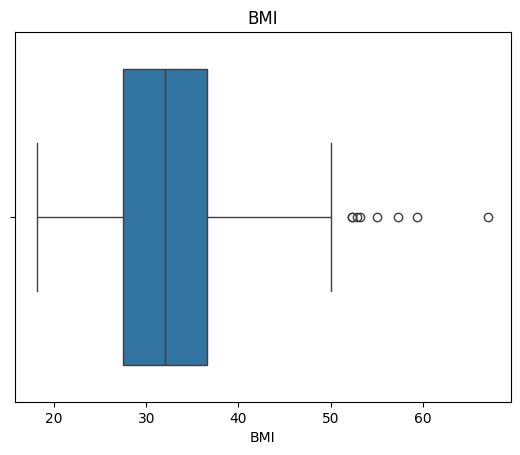

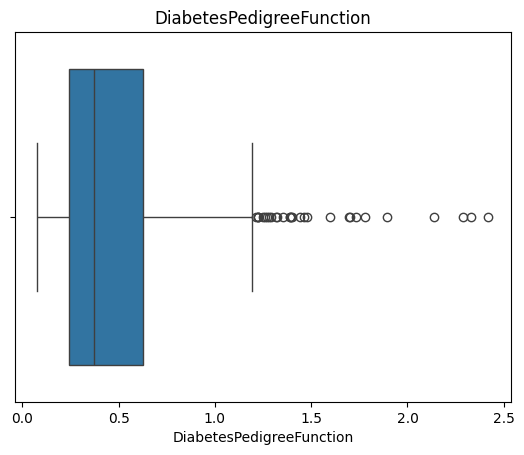

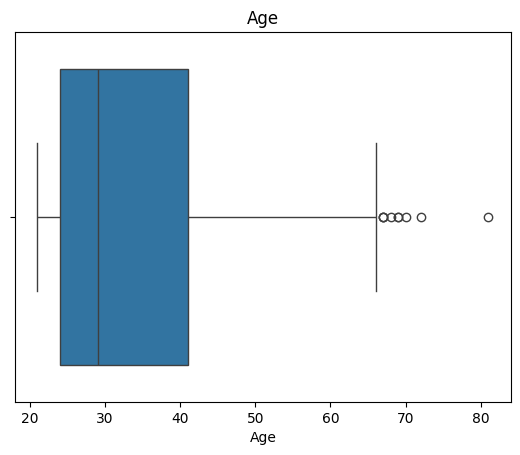

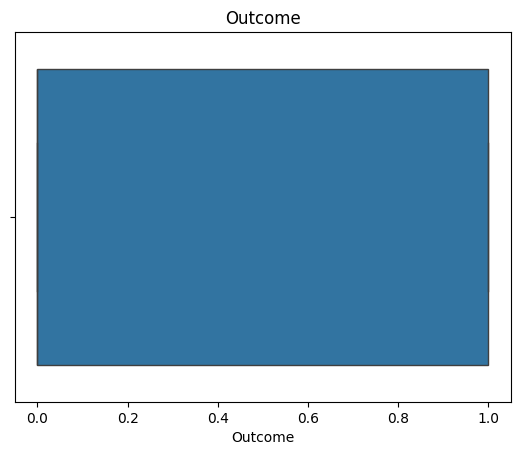

In [13]:
columns = ['Pregnancies','Glucose',	'BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction',	'Age','Outcome']
from matplotlib import pyplot as plt
import seaborn as sns
for col in columns:
    sns.boxplot(data=df,x=col)
    plt.title(col)
    plt.show()

In [19]:
df[['Insulin','DiabetesPedigreeFunction','SkinThickness','BloodPressure']].describe()

,Insulin,DiabetesPedigreeFunction,SkinThickness,BloodPressure
count,768.000000,768.000000,768.000000,768.000000
mean,86.139811,0.458914,27.116536,72.386719
std,76.287377,0.285596,8.447423,12.096642
min,14.000000,0.078000,9.500000,24.000000
25%,30.500000,0.243750,23.000000,64.000000
50%,31.250000,0.372500,23.000000,72.000000
75%,127.250000,0.626250,32.000000,80.000000
max,272.375000,1.200000,45.500000,122.000000


In [15]:
Q1 = df["Insulin"].quantile(0.25)
Q3 = df["Insulin"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Insulin"] = df["Insulin"].clip(lower=lower, upper=upper)

In [16]:
q1 = df["DiabetesPedigreeFunction"].quantile(0.25)
q3 = df["DiabetesPedigreeFunction"].quantile(0.75)
iqr = q3 - q1

Lower = q1 - 1.5 * iqr
Upper = q3 + 1.5 * iqr

df["DiabetesPedigreeFunction"] = df["DiabetesPedigreeFunction"].clip(lower=Lower, upper=Upper)

In [17]:
q_1 = df["SkinThickness"].quantile(0.25)
q_3 = df["SkinThickness"].quantile(0.75)
Iqr = q_3 - q_1

ll = q_1 - 1.5 * Iqr
ul = q_3 + 1.5 * Iqr

df["SkinThickness"] = df["SkinThickness"].clip(lower=ll, upper=ul)

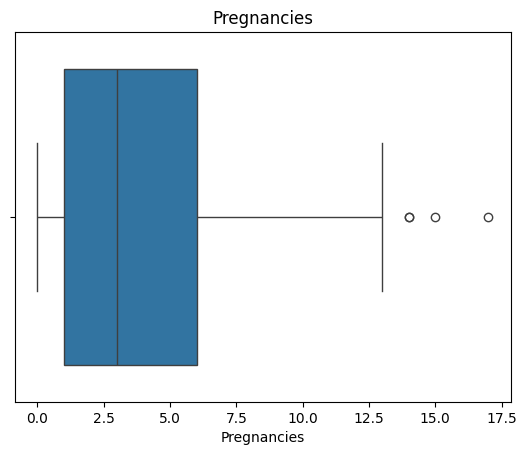

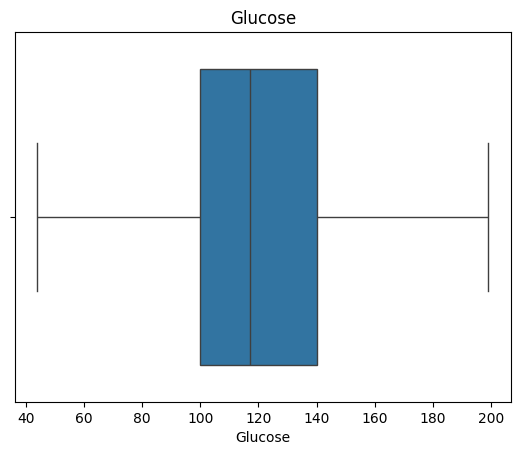

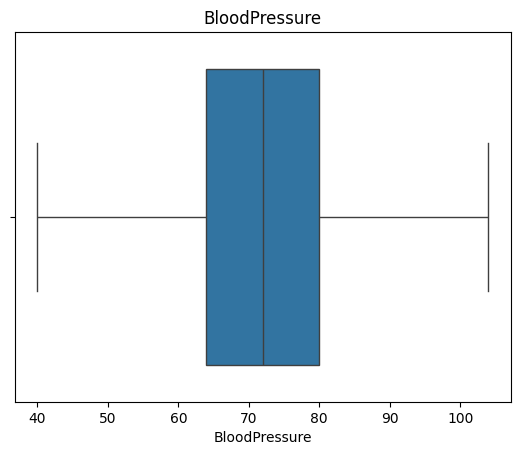

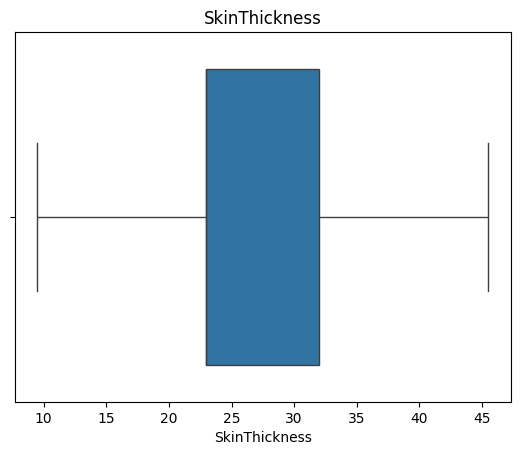

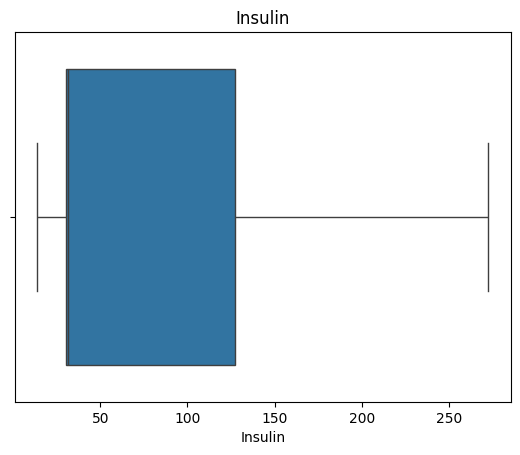

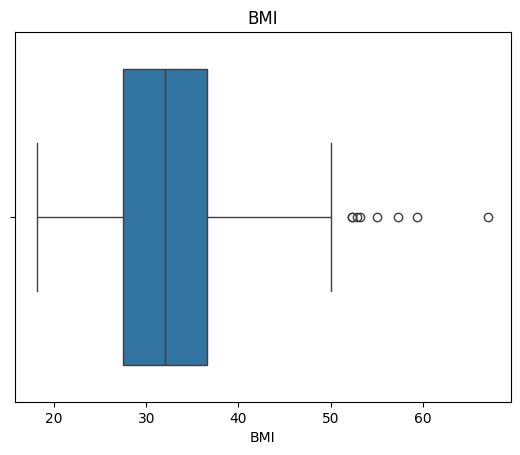

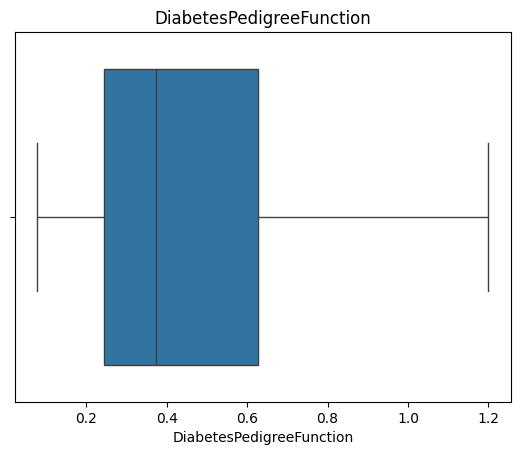

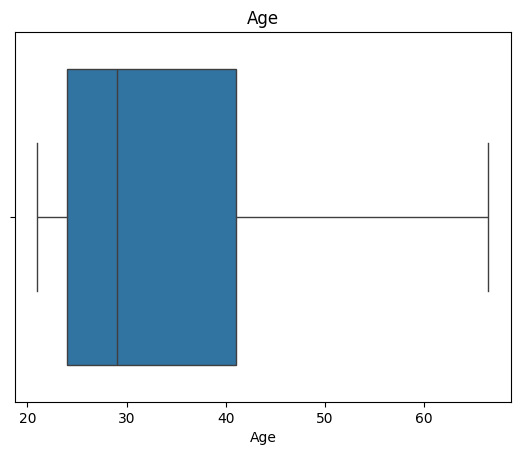

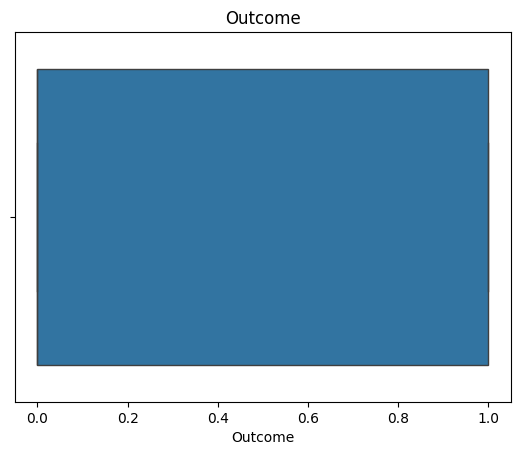

In [27]:
columns = ['Pregnancies','Glucose',	'BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction',	'Age','Outcome']
from matplotlib import pyplot as plt
import seaborn as sns
for col in columns:
    sns.boxplot(data=df,x=col)
    plt.title(col)
    plt.show()

In [24]:
q__1 = df["BloodPressure"].quantile(0.25)
q__3 = df["BloodPressure"].quantile(0.75)
i_q_r = q__3 - q__1

LL = q__1 - 1.5 * i_q_r
UL = q__3 + 1.5 * i_q_r

df["BloodPressure"] = df["BloodPressure"].clip(lower=LL, upper=UL)

In [26]:
Q__1 = df["Age"].quantile(0.25)
Q__3 = df["Age"].quantile(0.75)
i__q_r = Q__3 - Q__1

Ll = Q__1 - 1.5 * i__q_r
Ul = Q__3 + 1.5 * i__q_r

df["Age"] = df["Age"].clip(lower=Ll, upper=Ul)

In [28]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,30.5,33.6,0.627,50.0,1
1,1,85,66,29.0,30.5,26.6,0.351,31.0,0
2,8,183,64,23.0,30.5,23.3,0.672,32.0,1
3,1,89,66,23.0,94.0,28.1,0.167,21.0,0
4,0,137,40,35.0,168.0,43.1,1.200,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,45.5,180.0,32.9,0.171,63.0,0
764,2,122,70,27.0,30.5,36.8,0.340,27.0,0
765,5,121,72,23.0,112.0,26.2,0.245,30.0,0
766,1,126,60,23.0,30.5,30.1,0.349,47.0,1


In [29]:
X = df.drop('Outcome',axis=1)

In [30]:
y = df['Outcome']

In [55]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [56]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.fit_transform(X_test)

# ANN not good for this project. ANN needs large amount of data

In [34]:
#ANN
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [35]:
model1 = Sequential()

In [40]:
#input layer
input_layer = Dense(64,activation='relu',input_shape=(8,))
model1.add(input_layer)

#hidden layer
hidden_layer1 = Dense(32,activation='sigmoid')
model1.add(hidden_layer1)
#hidden layer
hidden_layer2 = Dense(32,activation='sigmoid')
model1.add(hidden_layer2)

#output layer
output_layer = Dense(32,activation='softmax')
model1.add(output_layer)

In [41]:
model1.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [43]:
model1.fit(X_train,y_train,epochs=200,batch_size=4)

Epoch 1/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6461
Epoch 2/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6481
Epoch 3/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6481
Epoch 4/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6499
Epoch 5/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6507
Epoch 6/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6502
Epoch 7/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6474
Epoch 8/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6545 - loss: 0.6478
Epoch 9/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6471
Epoch 10/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6484
Epoch 11/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.6485
Epoch 12/200
144/144 ━━━━━━━━━━━━━━━━━━━━

In [57]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [58]:
y_pred = lr.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score, classification_report
print('Accuracy:',accuracy_score(y_test,y_pred))
print('Classification Report:',classification_report(y_test,y_pred))

Accuracy: 0.7792207792207793
Classification Report:               precision    recall  f1-score   support

           0       0.81      0.89      0.84       157
           1       0.69      0.55      0.62        74

    accuracy                           0.78       231
   macro avg       0.75      0.72      0.73       231
weighted avg       0.77      0.78      0.77       231



In [70]:
from sklearn.svm import SVC
svm = SVC(kernel='linear')
svm.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
yPred = svm.predict(X_test)

In [72]:
print('Accuracy:',accuracy_score(y_test,yPred))
print('Classification Report:',classification_report(y_test,yPred))

Accuracy: 0.7792207792207793
Classification Report:               precision    recall  f1-score   support

           0       0.80      0.89      0.85       157
           1       0.70      0.54      0.61        74

    accuracy                           0.78       231
   macro avg       0.75      0.72      0.73       231
weighted avg       0.77      0.78      0.77       231



In [73]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion='log_loss',random_state=42)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'log_loss'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_Pred = rf.predict(X_test)

In [75]:
print('Accuracy of rf:',accuracy_score(y_test,y_Pred))
print('Classification Report of rf:',classification_report(y_test,y_Pred))

Accuracy of rf: 0.7402597402597403
Classification Report of rf:               precision    recall  f1-score   support

           0       0.79      0.83      0.81       157
           1       0.61      0.54      0.57        74

    accuracy                           0.74       231
   macro avg       0.70      0.69      0.69       231
weighted avg       0.73      0.74      0.74       231



In [76]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [77]:
YPred = xgb.predict(X_test)

In [78]:
print('Accuracy of xgb:',accuracy_score(y_test,YPred))
print('Classification Report of xgb:',classification_report(y_test,YPred))

Accuracy of xgb: 0.7575757575757576
Classification Report of xgb:               precision    recall  f1-score   support

           0       0.83      0.82      0.82       157
           1       0.62      0.64      0.63        74

    accuracy                           0.76       231
   macro avg       0.72      0.73      0.72       231
weighted avg       0.76      0.76      0.76       231

